# Image Processing

Start from this notebook before doing the others in this folder! The other notebooks depend on the directory structure set up in this one.

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn.objects as so
import seaborn as sns

import tifffile as tf

import palmettobug as pbug
import isosegdenoise as iSD

### CHANGE The following directory to match an existing directory on your computer if you are testing this tutorial on your own machine!

In [2]:
my_computer_path =  "C:/Users/caiello/Desktop"  ## CHANGE This DIRECTORY to match an existing directory on your computer if you testing this tutorial on your own machine!

## Set up a new directory and project

Here we:

    1). Set up a fresh directory on our computer that we wll place the project

    2). fetch the example data from PalmettoBUG into the project directory

    3). load the directory into a pbug.ImageAnalysis object

In [3]:
project_directory = f"{my_computer_path}/example_MCD_noGUI"
if not os.path.exists(project_directory):
    os.mkdir(project_directory)
pbug.fetch_IMC_example(project_directory)

In [4]:
resolutions = [1.0, 1.0]    ## in micrometers. 1 micron is standard IMC resolution
ImageAnalysis = pbug.imc_entrypoint(project_directory, resolutions =  resolutions, from_mcds = False)    ## The example data is available as .tiff files, because the mcd files are too large to bundle with the program easily.

## Next, set up the panel file:

In [5]:
display(ImageAnalysis.panel)

,channel,name,keep,segmentation
0,aSMA,aSMA,1,NaN
1,p-selectin,p-selectin,1,NaN
2,Vimentin,Vimentin,1,NaN
3,CD14,CD14,1,NaN
4,CD31,CD31,1,NaN
5,CD16,CD16,1,NaN
6,Pan-Keratin,Pan-Keratin,1,NaN
7,CD11b,CD11b,1,NaN
8,CD163,CD163,1,NaN
9,CD45,CD45,1,NaN


In [6]:
'''
Seeing the panel with the keep == 0 channels dropped is useful, as this will be the order of the channels in the .tiff files in /images/img, and therefore
the actual order of channels expected by certain steps of the program (such as pixel classification) when dealing with the images
## However -- in this case -- all the channels are to be kept, so it makes no difference
'''
#  ImageAnalysis.panel[ImageAnalysis.panel['keep'] == 1].reset_index().drop('index', axis = 1)
display()

In [7]:
'''
We must select our segmentation markers
'''
ImageAnalysis.panel.loc[25, "segmentation"] = 1         # H3
ImageAnalysis.panel.loc[29:31, "segmentation"] = 1      # DNA1 / 2
ImageAnalysis.panel.loc[31:, "segmentation"] = 2        # Seg 1-3

In [8]:
### The panel needs to be exported to the disc for record keeping, for loading the segmentation / denoiser ImageAnalysis class, and for reloading from the same directory with the same panel settings
ImageAnalysis.panel_write()  ## not needed if using a TableLaunch GUI to enter panel file values

## Now we can convert the /raw files to image files

This step does 4 things:

    1). Moves data from the /raw folder in the project directory --> to the /images/img folder
    
    2). If starting from MCDs, unpacks 1 .ome.tiff file in /images/img for every ROI in the MCDs

    3). If hpf > 0,  performs hot pixel filtering (see steinbock hot pixel filtering for what this does) to each image exported to /images/img

    4). Only exports channels with keep == 1 in the panel file

In this case, because we are starting from .ome.tiff files & all the channels have keep == 1, this effectively only runs hot pixel filtering while copying the example .
ome.tiff files from /raw to the images/img folder.

In [9]:
## convert MCDs ---> ome.tiff files. 
    ## with from_mcds = False, would convert Tiff --> ome.tiff, with the primary purpose being to hot pixel filter & to drop channels with keep = 0  in the panel file
ImageAnalysis.raw_to_img(hpf = 50)    # hpf = 50 is the default from steinbock

## do not worry about "Key not found: list index out of range" messages -- this is normal as part of reading / writing ome.tiffs (unfortunately, this is a print statement inside the dependency that handles
                                                                                                                         #     ome.tiff files, so it is not possible remove without changing that dependency)

Key not found: list index out of range
Key not found: list index out of range
key not found list index out of range
Key not found: list index out of range
Key not found: list index out of range
Key not found: list index out of range
key not found list index out of range
Key not found: list index out of range
Key not found: list index out of range
Key not found: list index out of range
key not found list index out of range
Key not found: list index out of range
Key not found: list index out of range
Key not found: list index out of range
key not found list index out of range
Key not found: list index out of range
Key not found: list index out of range
Key not found: list index out of range
key not found list index out of range
Key not found: list index out of range
Key not found: list index out of range
Key not found: list index out of range
key not found list index out of range
Key not found: list index out of range
Key not found: list index out of range
Key not found: list index out o

## Now do Segmentation 

(in isosegdenoise)

Here we load the project directory in iSD's paralell ImageAnalysis class, then perform deepcell segmentation.

To perform deepcell segmentation, we must:

    1). the images we what to segment (image_source_directory) -- this is typically the project's /images/img folder, unless additional image denoising / processing has been applied.
        It is also trivial to process the images outisde of palmettobug entirely, and then pass in those images to this function, as long as the order & number of channels remains the
        same inside the .tiff file.
    
    2). the names of the image(s) from that folder to segment. Can be ['ALL'] to segment all images in the folder, or can be a list of individual files in the folder.
    
    3). where we want the segmentation masks to be written (mask_output_directory), this is the /masks/deepcell folder in the GUI and this example. However, there is no restriction
        on where the output files can be written, so long as the destination folder can be created with os.mkdir(mask_output_directory). 

In [10]:
## initialize denoise / esgmentation ImageAnalysis:
seg_ImageAnalysis = iSD.imc_entrypoint(directory = project_directory, resolutions = resolutions, from_mcds = False)

In [11]:
'''
Select Deepcell segmentation parameters
'''
image_source_directory = ImageAnalysis.directory_object.img_dir + "/img"   
image_list = ['ALL']    ## either takes ['ALL'] (default) to segment all images, or a list of images (such as from os.listdir()), and will segment the first as a test

mask_output_directory = ImageAnalysis.directory_object.masks_dir + "/deepcell"

re_do = False           ## If set to False (default), will skip already segmented images (will not overwrite if image with same name already exists in output) 
                        ## Only used is image_list == ['All']

In [12]:
'''
Do Deepcell segmentation!
'''
seg_ImageAnalysis.deepcell_segment(image_folder = image_source_directory, output_folder = mask_output_directory, image_list = image_list, re_do = re_do)

No images to segment! Were you intending to redo segmentations, but re_do == False (default)?


(<Figure size 988.8x604.8 with 2 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x21f01520d00>)

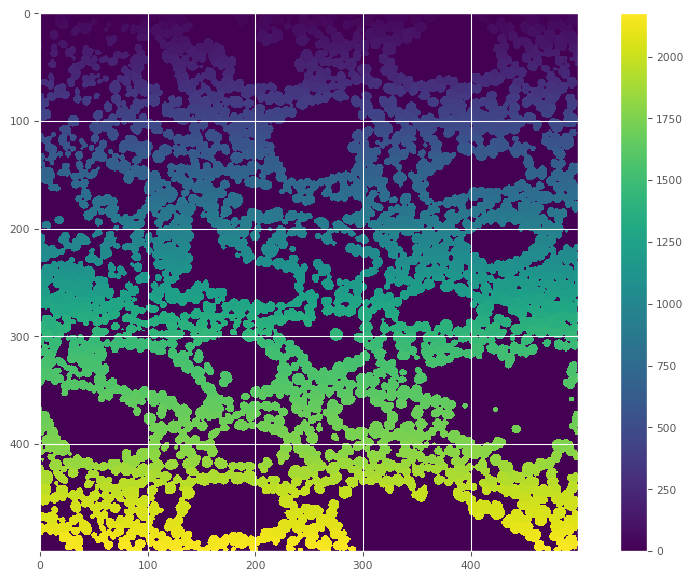

In [13]:
masks = os.listdir(mask_output_directory)
tf.imshow(tf.imread(mask_output_directory + "/" + masks[0]))

## Next make region measurements from the Segmentation masks.

This requires:

    1). an Analysis directory must be set up. This is a folder structure where the later Single-cell Analysis can be conducted.
        There can be multiple Analyses per one project (if, say, you were testing whether or not denoising certain channels made a 
        difference to the analysis, you could have a separate Analysis for each), so they are by default placed in the /Analyses folder
        of the project directory, only needing a unique folder name to be provided.

    2). The folder of images to make measurements off of    (input_img_folder)
    
    3). The folder of segmentation masks to define the regions where measurements will be taken     (input_mask_folder)

    4). The aggregate statistic to use on the values of the channels in the regions, such mean or median.

    5). The output folder for the intensities csv and the regionprops csvs (output_intensities_folder and output_regions_folder).

            -- These csv's are the same / similar as from steinbock's region measurement steps (on which this was derived)
                One csv of each type is generated for every image in the input_img_folder
            
            -- The intensities csv's contain the aggregate intensity of each channel within each segmentation region

            -- The regionprops csv's contain details about the segmentation masks, such as details related to the shape and
                location of each mask. 

While the input and output folders typically follow a set structure -- as they do in this example as well as in the GUI -- there is no theoretical restriction
on where you could input images / masks from or write them to, so there is flexbility in how this can be used. 

In [14]:
''' Name and setup the Analysis directory '''

analysis_folder_name = "MyAmazingAnalysis"
ImageAnalysis.directory_object.make_analysis_dirs(analysis_folder_name)

In [15]:
'''
Make measurements of the segmented / masked regions
'''

input_img_folder = ImageAnalysis.directory_object.img_dir + "/img"
input_mask_folder = ImageAnalysis.directory_object.masks_dir + "/deepcell"
output_intensities_folder = ImageAnalysis.directory_object.intensities_dir   # (default)
output_regions_folder = ImageAnalysis.directory_object.regionprops_dir       # (default)


statistic_options = ["sum", "min", "max", "mean","median","std","var"]
statistic = "mean"    ## this is the default, and rarely would you want to deviate from this

re_do = False    ## Determines if existing .csv's in the outputs folder wil be redone / overwritten or not. Naturally, this does not matter the first thme it is run.

ImageAnalysis.make_segmentation_measurements(input_img_folder, input_mask_folder, statistic = statistic, re_do = re_do, output_intensities_folder = output_intensities_folder, output_regions_folder = output_regions_folder)

All images have intensity and region files written! Did you intend to redo these measurements?


## Next, make the panel and metadata files for the Analysis

Preliminary panel and metadata can be easily generated with the to_analysis method, but will still need to be edited for actual use in a Single cell analysis.

Data that can't be automatically supplied by this method include:

    1). metadata --> patient_id and condition columns must be supplied by the user

    2). Analysis_panel --> marker_class (type, state, none)

However, in this case the example data comes bundled with a fully set-up analysis panel and metadata file, you we don't need to provide this information.

## Note: These cells will create 2 pop-up windows to assist you in editing the metadata / panel files! 

If you want to replicate the documentation, click Accept and Return without making any edits in the pop up windows

In [16]:
'''
Now, generate preliminary metadata / Analysis panel files -- if you have not created them already in another program like excel -- then edit
'''
panel, metadata, panel_path, metadata_path = ImageAnalysis.to_analysis(metadata_from_save = True)     ## we set metadata_from_save to True because of how the example is loaded from the package.

## Uncomment to show the intial panels:
# display(metadata)
# display(panel)

In [19]:
'''TableLaunches supply as easy & intuitive way to edit the preliminary versions of these files:'''
export_path =  panel_path
pbug.TableLaunch(dataframe = panel, table_type = "Analysis_panel", export_path = export_path,
             labels_editable = True,  width = 1.5, height = 1).mainloop()

export_path =  metadata_path
pbug.TableLaunch(dataframe = metadata, table_type = "metadata", export_path = export_path,
             labels_editable = True,  width = 1.5, height = 1).mainloop()

'''However, these files are already set up and do not need to be edited further, unless desired to test out the affects of different settings)'''
display()

## Load the analysis directory into the PalmettoBUG.Analysis class to begin Single-cell analysis

In [20]:
'''
Now that the proper analysis directory strucutre has been made and populated with .fcs files and the metadata and panel files, we can initiate an analysis
'''

Analysis_experiment = pbug.Analysis()
Analysis_experiment.load_data(ImageAnalysis.directory_object.Analysis_internal_dir)  ## Note how the directory here is the "internal_dir" 
#Analysis_experiment.load_fcs()                                                                                            # --> in your system's file explorer you see this as the "/main" folder inside the analysis folder

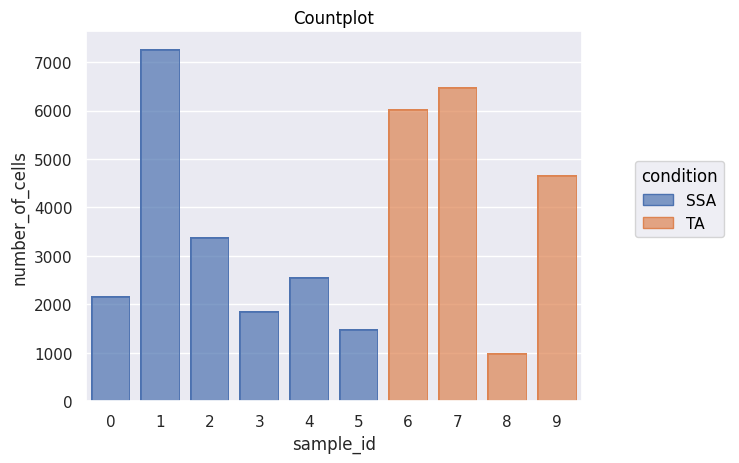

In [21]:
'''
Doing a single-cell data analysis in PalmettoBUG will be covered more in a different notebook -- but for this notebook I will generate a countplot just to show that
we have successfully entered the Analysis portion of the software!
'''
fig = Analysis_experiment.plot_cell_counts(group_by = "sample_id", color_by = "condition", filename = "countplot.png")
fig